# Logistic Regression

is a supervised learning algorithm used for binary classification,It predicts the probability that an input belongs to class 1 or 0.|

- It starts with our linear regression model 
  - $z = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$ 


- Then applies the sigmoid function to squash the output between 0 and 1
  - $σ(z) = \frac{1}{1+e^{-z}}\tag{1}$

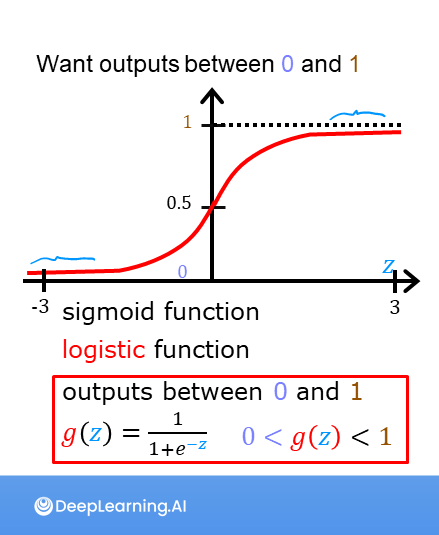


# Output

if  $σ(z) $>= 0.5 $--> predict =  1$


else $--> predict = 0$

---

In [407]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math


The `sigmoid` function is implemented in python as shown

In [408]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

In [409]:
z_tmp = np.arange(-10,11) # our input to the sigmoid fun
print(f"array of evenly spaced = {z_tmp}")

y = sigmoid(z_tmp)

array of evenly spaced = [-10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7
   8   9  10]


In [410]:
np.set_printoptions(precision=5,suppress=True) 
print("Input (z),  Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z),  Output (sigmoid(z))
[[-10.        0.00005]
 [ -9.        0.00012]
 [ -8.        0.00034]
 [ -7.        0.00091]
 [ -6.        0.00247]
 [ -5.        0.00669]
 [ -4.        0.01799]
 [ -3.        0.04743]
 [ -2.        0.1192 ]
 [ -1.        0.26894]
 [  0.        0.5    ]
 [  1.        0.73106]
 [  2.        0.8808 ]
 [  3.        0.95257]
 [  4.        0.98201]
 [  5.        0.99331]
 [  6.        0.99753]
 [  7.        0.99909]
 [  8.        0.99966]
 [  9.        0.99988]
 [ 10.        0.99995]]


The values in the left column are `z`, and the values in the right column are `sigmoid(z)`. As you can see, the input values to the sigmoid range from -10 to 10, and the output values range from 0 to 1. 

# Plot

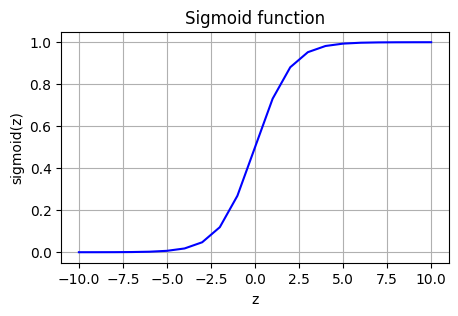

In [411]:
# Plot z vs sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
ax.grid()


---
# Decision Boundary

X = the input variable contains 6 examples

y = output variable contains 6 examples , and either 1,0

# Data plot

In [412]:
# 5 samples, 2 features
x = np.array([[0.5,1.5],[1,1],[1.5,0.5],
              [3,0.5],[2,2],[1,2.5]])

# 5 labels
y = np.array([[0,0,0,1,1,1]]).reshape(-1,1)

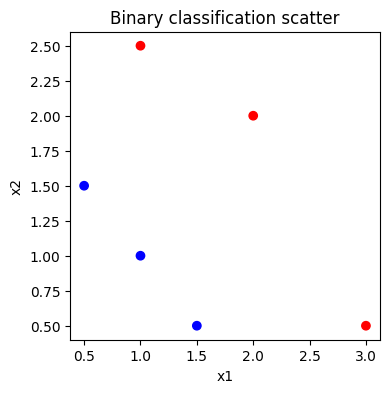

In [413]:

# Plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Binary classification scatter")
plt.show()


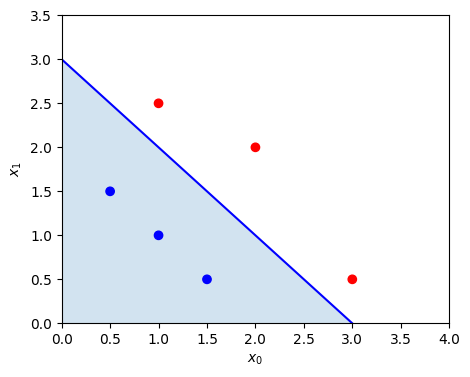

In [414]:
# Choose values between 0 and 6
x0 = np.arange(0,6)

x1 = 3 - x0
fig,ax = plt.subplots(1,1,figsize=(5,4))
# Plot the decision boundary
ax.plot(x0,x1, c="b")
ax.axis([0, 4, 0, 3.5])

# Fill the region below the line
ax.fill_between(x0,x1, alpha=0.2)

# Plot the original data
ax.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr')
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')
plt.show()

* In the plot above, the blue line represents the line $x_0 + x_1 - 3 = 0$ and it should intersect the x1 axis at 3 (if we set $x_1$ = 3, $x_0$ = 0) and the x0 axis at 3 (if we set $x_1$ = 0, $x_0$ = 3). 


* The shaded region represents $-3 + x_0+x_1 < 0$. The region above the line is $-3 + x_0+x_1 > 0$.


* Any point in the shaded region (under the line) is classified as $y=0$.  Any point on or above the line is classified as $y=1$. This line is known as the "decision boundary".


# logistic cost function

for **Linear** Regression we have used the **squared error cost function**:
The equation for the squared error cost with one variable is:
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$ 
 
where 
  $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$
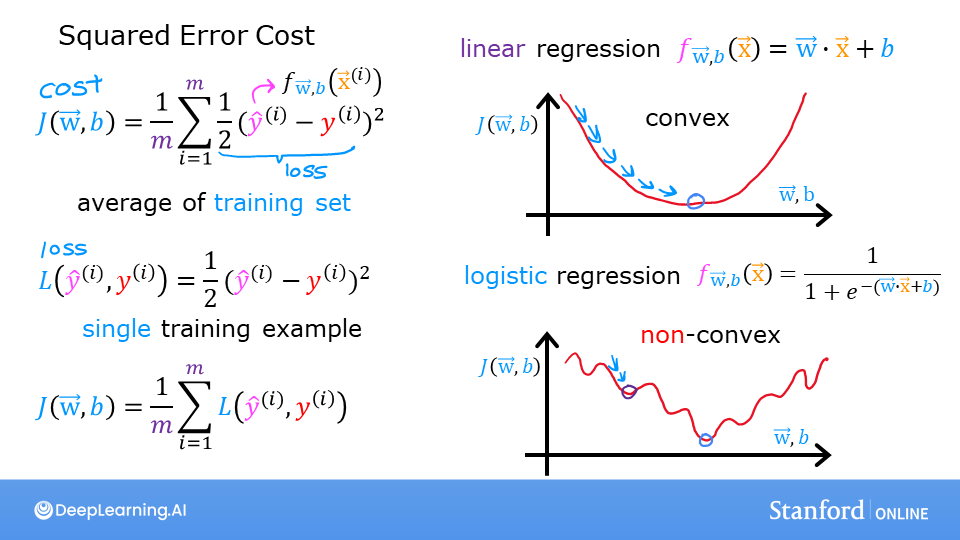

 the squared error cost had the nice property that following the derivative of the cost leads to the minimum.
 This cost function worked well for linear regression, it is natural to consider it for logistic regression as well. However, as the slide above points out,  𝑓𝑤𝑏(𝑥)
  now has a non-linear component, the sigmoid function:  𝑓𝑤,𝑏(𝑥(𝑖))=𝑠𝑖𝑔𝑚𝑜𝑖𝑑(𝑤𝑥(𝑖)+𝑏)

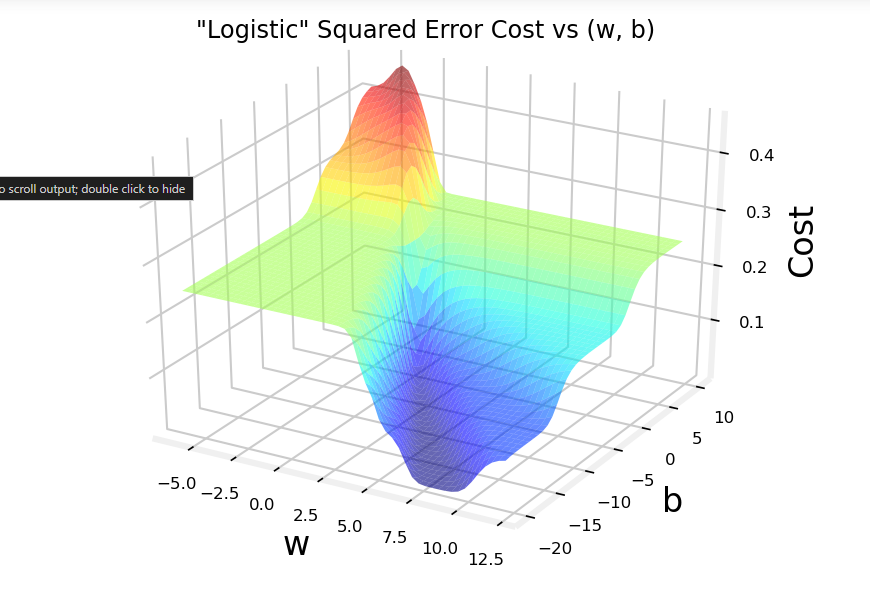


the surface above not nearly as smooth as the 'soup bowl' from linear regression!    

Logistic regression requires a cost function more suitable to its non-linear nature. This starts with a Loss function. This is described below.

## Logistic Loss Function


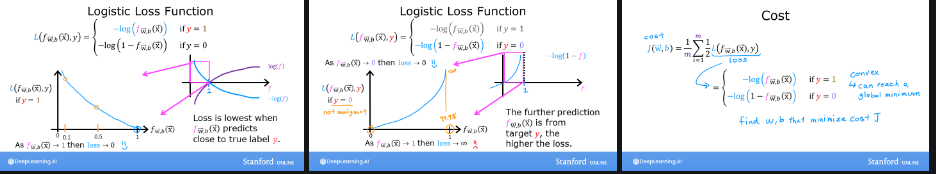

This is defined: 
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    - \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}


*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value.

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot\mathbf{x}^{(i)}+b)$ where function $g$ is the sigmoid function.
* Notational convention: `log` means the natural logarithm. 

The defining feature of this loss function is the fact that it uses two separate curves. One for the case when the target is zero or ($y=0$) and another for when the target is one ($y=1$). Combined, these curves provide the behavior useful for a loss function, namely, being zero when the prediction matches the target and rapidly increasing in value as the prediction differs from the target. Consider the curves below:

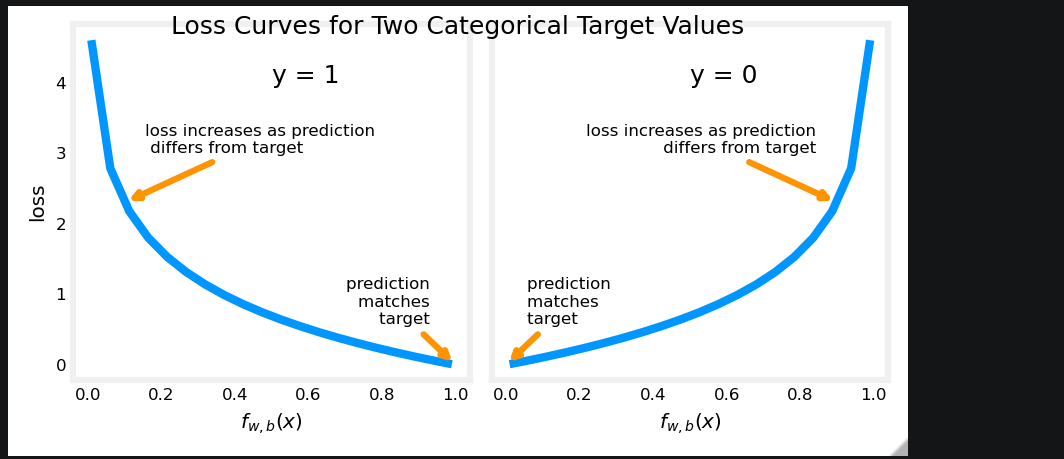

# Example 

In [415]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])  

In [416]:
X_train.shape,y_train.shape

((6, 2), (6,))

Text(0.5, 0, '$x_2$')

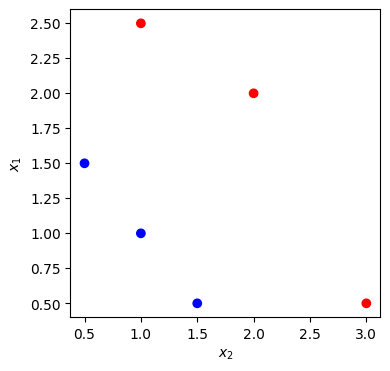

In [417]:
fig,ax = plt.subplots(1,1,figsize=(4,4),)

ax.scatter(X_train[:,0],X_train[:,1],c = y_train,cmap='bwr',) 
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_2$')

## Cost function




Recall that for logistic regression, the cost function is of the form 

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
*  where m is the number of training examples in the data set and:
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$
 

In [418]:
def compute_cost_logistic(x,y,w,b):
    m = x.shape[0]
    cost = 0.0

    for i in range(m):
        z_i = np.dot(x[i],w) + b

        f_wb_i = sigmoid(z_i) # prediction (y_h) 

        cost+= -y[i]* np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i) 

    cost = cost/m

    return cost

In [419]:
w_tmp = np.array([1,1])
b_tmp = -3
print(f"cost:{compute_cost_logistic(X_train, y_train, w_tmp, b_tmp)}")

cost:0.36686678640551745


In [420]:
x = np.array([[0.2], [0.7], [1.5]])
y = np.array([0, 1, 1])
w = np.array([2.0])
b = -1

print("Cost:", compute_cost_logistic(x, y, w, b))


Cost: 0.3591437379762703


---

# Gradient descent for logistic regression

Recall the gradient descent algorithm utilizes the gradient calculation:
$$\begin{align*}
&\text{repeat until convergence:} \; \lbrace \\
&  \; \; \;w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1} \\ 
&  \; \; \;  \; \;b = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
&\rbrace
\end{align*}$$

Where each iteration performs simultaneous updates on $w_j$ for all $j$, where
$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2} \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3} 
\end{align*}$$

* m is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target
* For a logistic regression model  
    $z = \mathbf{w} \cdot \mathbf{x} + b$  
    $f_{\mathbf{w},b}(x) = g(z)$  
    where $g(z)$ is the sigmoid function:  
    $g(z) = \frac{1}{1+e^{-z}}$   

In [421]:
def compute_gradient_logistic(x, y, w, b):
    
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        y_hat = sigmoid(np.dot(x[i], w) + b)
        error = y_hat - y[i]

        dj_dw += error * x[i]    
        dj_db += error           # scalar bias
   
    dj_dw = dj_dw/m                                   
    dj_db = dj_db/m                                  
        
    return dj_db, dj_dw

In [422]:
# run the function above
w_tmp = np.array([2.,3.])
b_tmp = 1.
dj_db_tmp, dj_dw_tmp = compute_gradient_logistic(X_train, y_train, w_tmp, b_tmp)
print(f"dj_db: {dj_db_tmp}" )
print(f"dj_dw: {dj_dw_tmp}" )

dj_db: 0.49861806546328574
dj_dw: [0.49833 0.49884]


In [423]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
   
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( compute_cost_logistic(X, y, w, b) )

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i % math.ceil(num_iters/10)==0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
        
    return w, b, J_history         #return final w,b and J history for graphing


In [424]:
w_tmp  = np.zeros_like(X_train[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _, = gradient_descent(X_train, y_train, w_tmp, b_tmp,alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870457   
Iteration 2000: Cost 0.08460064176930078   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.04290759421682   
Iteration 5000: Cost 0.03433847729884557   
Iteration 6000: Cost 0.02860379802212006   
Iteration 7000: Cost 0.02450156960879306   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   

updated parameters: w:[5.28123 5.07816], b:-14.222409982019837


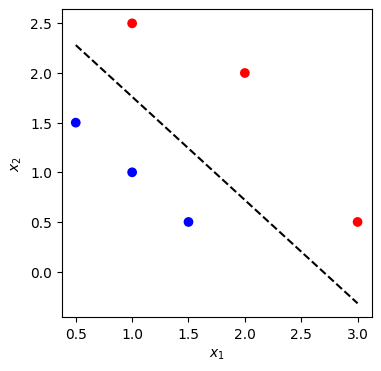

In [425]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Plot data points
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

# Plot decision boundary: x2 = -(w0/w1)*x1 - b/w1
x_vals = np.array([X_train[:, 0].min(), X_train[:, 0].max()])
y_vals = -(w_out[0] / w_out[1]) * x_vals - b_out / w_out[1]
ax.plot(x_vals, y_vals, 'k--')  # black dashed line

plt.show()
